<table class="table table-bordered">
    <tr>
        <th style="width:200px;">
            <img src='https://bcgriseacademy.com/hs-fs/hubfs/RISE%202.0%20Logo_Options_25Jan23_RISE%20-%20For%20Black%20Background.png?width=3522&height=1986&name=RISE%202.0%20Logo_Options_25Jan23_RISE%20-%20For%20Black%20Background.png' style="background-color:black; width: 100%; height: 100%;">
        </th>
        <th style="text-align:center;">
            <h1>RISE2.0 Business and Data Analytics</h1>
            <h2>IU 3.7.2.1 Machine Learning Project</h2>
            <h3>Business Case 2 - Unsupervised Learning</h3>
        </th>
    </tr>
</table>

## Context

You are a data analyst working in a retail bank based in the Middle East, where they have been doing traditional mass marketing campaigns for years. The bank is now keen to explore the benefits of running tailored marketing campaigns for their customer base.

## Business problem

The retail bank is facing a couple of challenges:
1. Profitability pressure from reduced utilization by existing customers
2. Increasingly competitive landscape where other banks are running personalized ad campaigns using differentiated products and services

## Project objectives and description

In this discovery phase, the objective is to understand the various segments that exist in the bank's customer base, based on the customers' demographics and utilization patterns.

## Dataset

You are provided with the following files:
1. bank_customers.csv
2. Data Dictionary - Bank Customers.xlsx
___

## Step 1: Initial Setup

In [4]:
# Import the required packages
import warnings
warnings.filterwarnings('ignore')

import math
import statistics
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

#### 1.1 Read the raw CSV file from the Data folder into pandas.

In [6]:
bank_cust = pd.read_csv('./Data/bank_customers.csv')

#### 1.2 View the first 5 rows of the data.

In [8]:
bank_cust.head(5)

,Customer No,Customer Nationality,Customer Age,Account Opening Date,DC Spends,SALARY_FLAG,DR_FLAG,Bill Payment,CC Spends,Monthly Average Balance
0,353446,INDIA,67,17/08/2017,Active,No Salary,No DR,No Bill,No CC,1820.582258
1,99061,PHILIPPINES,71,13/11/2020,Inactive,Salary with Bank,No DR,Active Bill,No CC,94.028387
2,344207,GREECE,56,8/11/2018,Inactive,No Salary,Inactive DR,Inactive Bill,Inactive CC,5020.710000
3,496773,GHANA,40,16/07/2019,Active,Salary with Bank,Active DR,No Bill,Active CC,0.000000
4,39530,PHILIPPINES,57,25/11/2017,Active,No Salary,Inactive DR,Active Bill,No CC,196.214839


___
## Step 2: Data Exploration [5 marks]

#### 2.1 Find the shape and data types of the dataset

In [11]:
print("Shape:", bank_cust.shape)
print("---------------")
print("Data type: ")
print(bank_cust.info())

Shape: (1000, 10)
---------------
Data type: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer No              1000 non-null   int64  
 1   Customer Nationality     1000 non-null   object 
 2   Customer Age             1000 non-null   int64  
 3   Account Opening Date     1000 non-null   object 
 4   DC Spends                1000 non-null   object 
 5   SALARY_FLAG              1000 non-null   object 
 6   DR_FLAG                  1000 non-null   object 
 7   Bill Payment             1000 non-null   object 
 8   CC Spends                1000 non-null   object 
 9   Monthly Average Balance  1000 non-null   float64
dtypes: float64(1), int64(2), object(7)
memory usage: 78.3+ KB
None


#### 2.2 Convert the columns to the appropriate data types (wherever necessary).
- HINT: Review date related columns

In [13]:
bank_cust['Account Opening Date'] = pd.to_datetime(bank_cust['Account Opening Date'], dayfirst=True)
bank_cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Customer No              1000 non-null   int64         
 1   Customer Nationality     1000 non-null   object        
 2   Customer Age             1000 non-null   int64         
 3   Account Opening Date     1000 non-null   datetime64[ns]
 4   DC Spends                1000 non-null   object        
 5   SALARY_FLAG              1000 non-null   object        
 6   DR_FLAG                  1000 non-null   object        
 7   Bill Payment             1000 non-null   object        
 8   CC Spends                1000 non-null   object        
 9   Monthly Average Balance  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 78.3+ KB


#### 2.3 Check if there are any null values in the columns.

In [15]:
bank_cust.isnull().sum()

Customer No                0
Customer Nationality       0
Customer Age               0
Account Opening Date       0
DC Spends                  0
SALARY_FLAG                0
DR_FLAG                    0
Bill Payment               0
CC Spends                  0
Monthly Average Balance    0
dtype: int64

#### 2.4 For each categorical column, count the number of unique categories.
- HINT: Instead of doing it one by one, filter by dtypes that are equal to object, and print the unique count using `.nunique()`

In [17]:
obj_cols = bank_cust.select_dtypes(include=['object'])
obj_cols.nunique()

Customer Nationality    62
DC Spends                3
SALARY_FLAG              3
DR_FLAG                  3
Bill Payment             3
CC Spends                3
dtype: int64

#### 2.5 For numerical columns, check the data distributions using appropriate functions and plots (e.g., box plots).

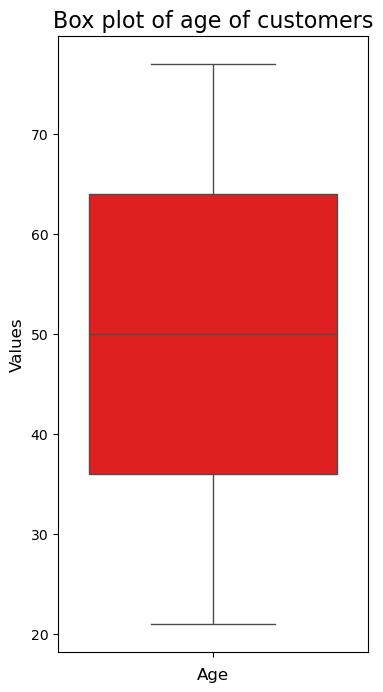

In [19]:
Age = bank_cust['Customer Age']
plt.figure(figsize=(4,8))
sns.boxplot(data=Age, color='Red')

plt.title('Box plot of age of customers', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.show()

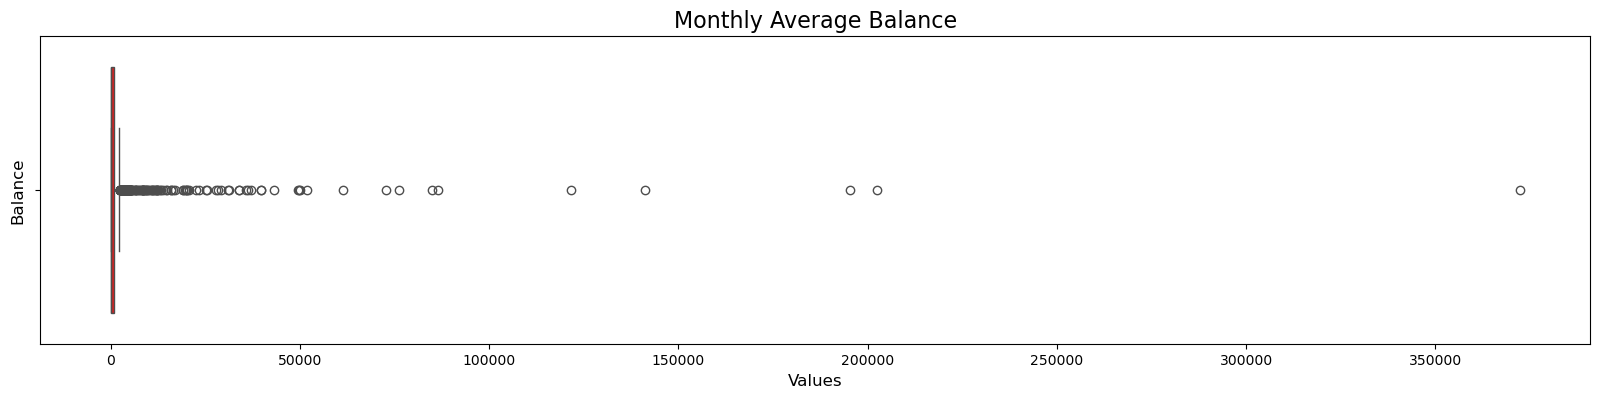

In [20]:
Balance = bank_cust['Monthly Average Balance']
plt.figure(figsize=(20,4))
sns.boxplot(data=Balance, color='Red', orient='h')

plt.title('Monthly Average Balance', fontsize=16)
plt.xlabel('Values', fontsize=12)
plt.ylabel('Balance', fontsize=12)
plt.show()

**Note**
- For this dataset, there are a few very large values (outliers) in the monthly average balance.
- Instead of dropping outliers, we will convert them into categories in the next step. 
- Note that dropping outliers is a bad move if we do not know exactly what is going on. For bank accounts, there will definitely be outliers because some customers are more wealthy than the rest. These are not data errors, so they should not be dropped just because they are 'inconvenient' for our analysis.

___
## Step 3: Data preprocessing [12 marks]

The goal here is to convert all values to numerical so that record of each customer will be in the form of numeric feature vectors

#### 3.1 Create a new column `Tenure` for the number of months (rounded to nearest integer) since the customer has opened the account.
- HINT: The snapshot date is 01 Mar 2022, so you should find the date difference between the snapshot date and the account opening date.

In [24]:
bank_cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Customer No              1000 non-null   int64         
 1   Customer Nationality     1000 non-null   object        
 2   Customer Age             1000 non-null   int64         
 3   Account Opening Date     1000 non-null   datetime64[ns]
 4   DC Spends                1000 non-null   object        
 5   SALARY_FLAG              1000 non-null   object        
 6   DR_FLAG                  1000 non-null   object        
 7   Bill Payment             1000 non-null   object        
 8   CC Spends                1000 non-null   object        
 9   Monthly Average Balance  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 78.3+ KB


In [25]:
from datetime import datetime

snapshot = datetime(2022, 3, 1)
bank_cust['Tenure'] = (snapshot.year - bank_cust['Account Opening Date'].dt.year) * 12 + \
                      (snapshot.month - bank_cust['Account Opening Date'].dt.month)

bank_cust.head(5)

,Customer No,Customer Nationality,Customer Age,Account Opening Date,DC Spends,SALARY_FLAG,DR_FLAG,Bill Payment,CC Spends,Monthly Average Balance,Tenure
0,353446,INDIA,67,2017-08-17,Active,No Salary,No DR,No Bill,No CC,1820.582258,55
1,99061,PHILIPPINES,71,2020-11-13,Inactive,Salary with Bank,No DR,Active Bill,No CC,94.028387,16
2,344207,GREECE,56,2018-11-08,Inactive,No Salary,Inactive DR,Inactive Bill,Inactive CC,5020.710000,40
3,496773,GHANA,40,2019-07-16,Active,Salary with Bank,Active DR,No Bill,Active CC,0.000000,32
4,39530,PHILIPPINES,57,2017-11-25,Active,No Salary,Inactive DR,Active Bill,No CC,196.214839,52


#### 3.2 Clean the `Monthly Average Balance` column by converting all negative balance values to 0.

In [27]:
bank_cust.loc[bank_cust['Monthly Average Balance'] < 0, 'Monthly Average Balance'] = 0
neg_count = (bank_cust['Monthly Average Balance'] < 0).sum()

print(f"Number of negative values: {neg_count}")

Number of negative values: 0


#### 3.3 Rather than discarding outliers, we want to group customers into the following categories based on the following monthly average balance deciles. 

- $\ge$95%: 'Very High'
- $\ge$80% - 95%: 'High'
- $\ge$50% - 80%: 'Middle'
- $\lt$50%: 'Normal'

#### Create Python variables to store these decile cutoffs.
- HINT: Only need to create 3 variables to indicate Very High, High, and Middle. Use the `.quantile` method

In [29]:
q_50 = bank_cust['Monthly Average Balance'].quantile(0.5)
q_80 = bank_cust['Monthly Average Balance'].quantile(0.8)
q_95 = bank_cust['Monthly Average Balance'].quantile(0.95)

def categorize_balance(balance):
    if balance <= q_50:
        return "Normal"
    elif balance >= q_50 and balance < q_80:
        return "Middle"
    elif balance >= q_80 and balance < q_95:
        return "High"
    else:
        return "Very High"

bank_cust['Balance Category'] = bank_cust['Monthly Average Balance'].apply(categorize_balance)
bank_cust.head(5)

,Customer No,Customer Nationality,Customer Age,Account Opening Date,DC Spends,SALARY_FLAG,DR_FLAG,Bill Payment,CC Spends,Monthly Average Balance,Tenure,Balance Category
0,353446,INDIA,67,2017-08-17,Active,No Salary,No DR,No Bill,No CC,1820.582258,55,High
1,99061,PHILIPPINES,71,2020-11-13,Inactive,Salary with Bank,No DR,Active Bill,No CC,94.028387,16,Middle
2,344207,GREECE,56,2018-11-08,Inactive,No Salary,Inactive DR,Inactive Bill,Inactive CC,5020.710000,40,High
3,496773,GHANA,40,2019-07-16,Active,Salary with Bank,Active DR,No Bill,Active CC,0.000000,32,Normal
4,39530,PHILIPPINES,57,2017-11-25,Active,No Salary,Inactive DR,Active Bill,No CC,196.214839,52,Middle


In [30]:
bank_cust.rename(columns={"Bank Category": "Balance Level"}, inplace=True)
bank_cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Customer No              1000 non-null   int64         
 1   Customer Nationality     1000 non-null   object        
 2   Customer Age             1000 non-null   int64         
 3   Account Opening Date     1000 non-null   datetime64[ns]
 4   DC Spends                1000 non-null   object        
 5   SALARY_FLAG              1000 non-null   object        
 6   DR_FLAG                  1000 non-null   object        
 7   Bill Payment             1000 non-null   object        
 8   CC Spends                1000 non-null   object        
 9   Monthly Average Balance  1000 non-null   float64       
 10  Tenure                   1000 non-null   int32         
 11  Balance Category         1000 non-null   object        
dtypes: datetime64[ns](1), float64(1), i

In [31]:
bank_cust.describe()

,Customer No,Customer Age,Account Opening Date,Monthly Average Balance,Tenure
count,1000.000000,1000.000000,1000,1000.000000,1000.000000
mean,245215.013000,49.540000,2019-08-29 02:48:28.800000,3263.509362,30.566000
min,26.000000,21.000000,2017-01-31 00:00:00,0.000000,0.000000
25%,116036.250000,36.000000,2018-04-18 06:00:00,0.000000,14.000000
50%,239983.000000,50.000000,2019-08-18 00:00:00,15.750000,31.000000
75%,368319.750000,64.000000,2021-01-08 06:00:00,908.245968,47.000000
max,499963.000000,77.000000,2022-03-31 00:00:00,372334.503500,62.000000
std,144281.883775,16.328534,NaN,17576.049212,17.899498


In [32]:
bank_cust['Monthly Average Balance'].quantile(0.95)

12083.372146999995

In [33]:
bank_cust['Balance Level'] = pd.cut(bank_cust['Monthly Average Balance'],
                                    bins=[-0.01,16,1719,12084,99999999],
                                    labels=[1,2,3,4],
                                    include_lowest=True)

bank_cust.head(5)

,Customer No,Customer Nationality,Customer Age,Account Opening Date,DC Spends,SALARY_FLAG,DR_FLAG,Bill Payment,CC Spends,Monthly Average Balance,Tenure,Balance Category,Balance Level
0,353446,INDIA,67,2017-08-17,Active,No Salary,No DR,No Bill,No CC,1820.582258,55,High,3
1,99061,PHILIPPINES,71,2020-11-13,Inactive,Salary with Bank,No DR,Active Bill,No CC,94.028387,16,Middle,2
2,344207,GREECE,56,2018-11-08,Inactive,No Salary,Inactive DR,Inactive Bill,Inactive CC,5020.710000,40,High,3
3,496773,GHANA,40,2019-07-16,Active,Salary with Bank,Active DR,No Bill,Active CC,0.000000,32,Normal,1
4,39530,PHILIPPINES,57,2017-11-25,Active,No Salary,Inactive DR,Active Bill,No CC,196.214839,52,Middle,2


#### 3.5 For categorical columns, convert them to numeric format.
- Hint: use pandas dummy encoding 

In [35]:
from sklearn.preprocessing import LabelEncoder

for col in bank_cust.columns:
    if bank_cust[col].dtype == 'object':
        le = LabelEncoder()
        bank_cust[col] = le.fit_transform(bank_cust[col])

bank_cust.head(5)

,Customer No,Customer Nationality,Customer Age,Account Opening Date,DC Spends,SALARY_FLAG,DR_FLAG,Bill Payment,CC Spends,Monthly Average Balance,Tenure,Balance Category,Balance Level
0,353446,19,67,2017-08-17,0,0,2,2,2,1820.582258,55,0,3
1,99061,41,71,2020-11-13,1,1,2,0,2,94.028387,16,1,2
2,344207,17,56,2018-11-08,1,0,1,1,1,5020.710000,40,0,3
3,496773,16,40,2019-07-16,0,1,0,2,0,0.000000,32,2,1
4,39530,41,57,2017-11-25,0,0,1,0,2,196.214839,52,1,2


#### 3.6 Drop columns that are no longer informative for downstream clustering.
- `Customer No`, `Customer Nationality`, `Account Opening Date`, `Monthly Average Balance`

In [37]:
drop_cols = ['Customer No', 'Customer Nationality', 'Account Opening Date', 'Monthly Average Balance']
bank_cust_new = bank_cust.drop(columns=drop_cols)
bank_cust_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Customer Age      1000 non-null   int64   
 1   DC Spends         1000 non-null   int32   
 2   SALARY_FLAG       1000 non-null   int32   
 3   DR_FLAG           1000 non-null   int32   
 4   Bill Payment      1000 non-null   int32   
 5   CC Spends         1000 non-null   int32   
 6   Tenure            1000 non-null   int32   
 7   Balance Category  1000 non-null   int32   
 8   Balance Level     1000 non-null   category
dtypes: category(1), int32(7), int64(1)
memory usage: 36.5 KB


#### 3.6 Standardize the numerical values in the dataset.
Note: Perform min max scaling

In [39]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_cols = bank_cust_new.select_dtypes(include=['number']).columns
bank_cust_new[num_cols] = pd.DataFrame(scaler.fit_transform(bank_cust[num_cols]))

bank_cust_new

,Customer Age,DC Spends,SALARY_FLAG,DR_FLAG,Bill Payment,CC Spends,Tenure,Balance Category,Balance Level
0,0.821429,0.0,0.0,1.0,1.0,1.0,0.887097,0.000000,3
1,0.892857,0.5,0.5,1.0,0.0,1.0,0.258065,0.333333,2
2,0.625000,0.5,0.0,0.5,0.5,0.5,0.645161,0.000000,3
3,0.339286,0.0,0.5,0.0,1.0,0.0,0.516129,0.666667,1
4,0.642857,0.0,0.0,0.5,0.0,1.0,0.838710,0.333333,2
...,...,...,...,...,...,...,...,...,...
995,0.642857,0.0,1.0,0.0,1.0,0.0,0.419355,0.333333,2
996,0.017857,0.0,1.0,1.0,0.0,1.0,0.790323,0.666667,1
997,0.410714,0.5,1.0,1.0,0.5,0.0,0.532258,0.666667,1
998,0.839286,0.5,0.0,0.0,0.0,1.0,0.258065,0.666667,1


___
## Step 4: K-Means Clustering [12 marks]
#### The objective is to:
- Find the most appropriate k value using the Elbow method
- Calculate and store the silhouette coefficient values

#### 4.1 Create a baseline k-means model with `k=3` and `random_state=0` by fitting on the scaled data.

In [42]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(bank_cust_new)

KMeans(n_clusters=3, random_state=0)

#### 4.2 Obtain the inertia value and silhouette score of this model.
HINT: For silhouette score, you will need to first get predictions with `fit_predict`

In [44]:
from sklearn.metrics import silhouette_score

inertia = kmeans.inertia_
silhouette = silhouette_score(bank_cust_new, kmeans.labels_)

print(f"Inertia: {inertia}")
print(f"Silhouette Score: {silhouette}")

Inertia: 1115.9199372584642
Silhouette Score: 0.24827523719172767


#### 4.3 Repeat the above two steps but for the range of k values from 2 to 12. Save the inertia scores and silhouette scores in separate dictionaries.

In [46]:
inertia_score = []
silhouette_scores = []

for k in range(2, 13):
    kmeans = KMeans(n_clusters = k, random_state = 0)
    kmeans.fit(bank_cust_new)

    inertia_score.append(kmeans.inertia_)

    silhouette_scores.append(silhouette_score(bank_cust_new, kmeans.labels_))

print(f"Inertia: \n{inertia_score}\n")
print(f"Silhouette Score: \n{silhouette_scores}")


Inertia: 
[1288.0631881385568, 1115.9199372584642, 1004.2453442462624, 962.2949678564808, 898.8321682712193, 861.0157186303965, 832.4087205346809, 801.3498597414897, 772.2363696436546, 749.6502516946865, 742.1967798071253]

Silhouette Score: 
[0.3428514054362315, 0.24827523719172767, 0.21531203163256496, 0.17167534652049438, 0.1429804878322664, 0.13545971443308663, 0.13166290207129014, 0.13320874061740537, 0.13665184823101512, 0.13383202900043453, 0.1266441086219058]


#### 4.4 Use the Elbow method (by showing the plot) to determine the optimal number of clusters. 

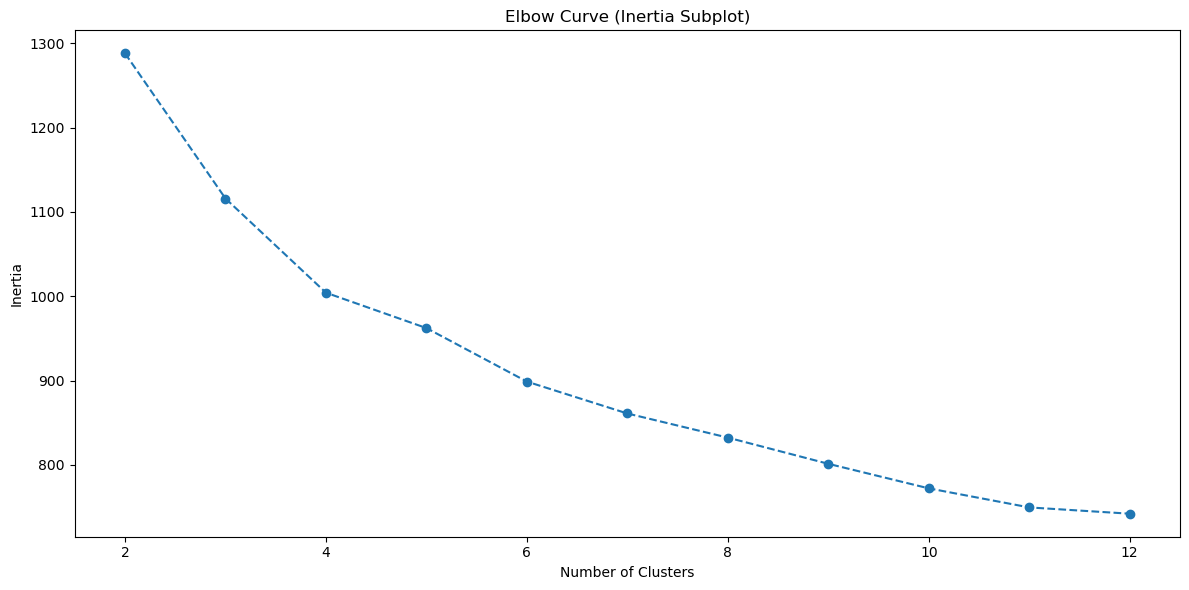

In [48]:
plt.figure(figsize=(12,6))
plt.subplot(1,1,1)
plt.plot(range(2,13), inertia_score, linestyle='dashed', marker='o')
plt.title("Elbow Curve (Inertia Subplot)")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.tight_layout()
plt.show()

#### 4.5 Use the Silhouette method (by with showing the plot) to determine the optimal number of clusters. 
- HINT: This part is NOT about generating the silhouette analysis graphs. Instead, repeat the code in Step 4.4, but instead of using inertia values, use the silhouette scores that you have already saved from Step 4.3

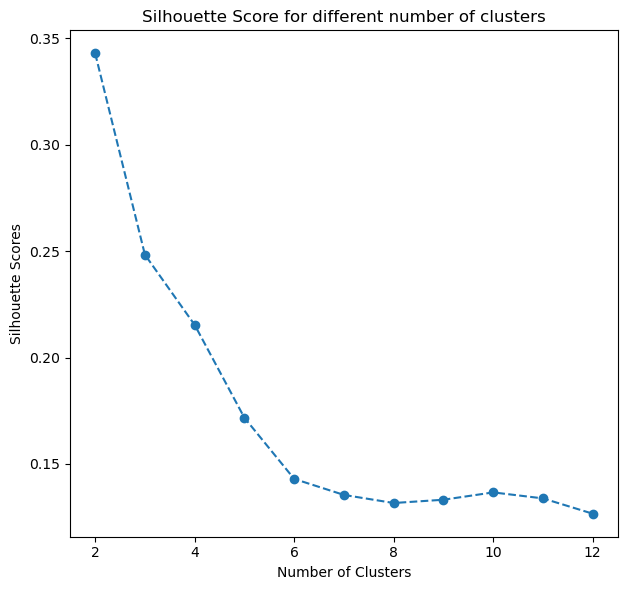

In [50]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(range(2,13), silhouette_scores, linestyle='dashed', marker='o')
plt.title("Silhouette Score for different number of clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Scores")

plt.tight_layout()
plt.show()

#### 4.6 What can we summarize from the elbow and silhouette plots, and what is the optimal cluster number you would choose?

Answer: 

By the elbow method, we can see that the elbow point is at k=4. For the silhouette score method, we can see that the highest score peaks at k=2.

Since the bank is keen on exploring tailored marketing campaign but also have concerns from profitability and competition issues, I would choose k=2 for simpler segmentation.

___
## Step 5: Generating Cluster Labels [5 marks]

#### 5.1 Generate the predicted labels for each customer in the dataset, and save it the output array in a variable called `labels`.
- HINT: Use `fit_predict`

In [55]:
labels = kmeans.fit_predict(bank_cust_new)

print("Predicted Labels: \n", labels)

Predicted Labels: 
 [ 2  7  2  9  7  8  6  1  2  4  6 10  6 11  1 10 10  3  7  6  3  7  9  7
  4  5  1  9  4  6  8  2  3 10  9  8  4  6  4  2  3  5  6  6  0  4  3  6
  1  0  2  4  6 10  5  5  4  0 11 11  2  2  9  1  1  3  4  1  5  3  7  4
  3  3  2 10  9  4  6  5  6  4  6  5  6  5  1  5  8  4  1  2  3  6  9  1
  9  3  9  0  7  6  8  3  9  4  1  5  5 10  3  6  1 10  5  7  6  7  3  8
  6 10 10  3 10  8  6  7  4  2  3  4  3  4  6  4  9  1  9  2  8  5  5  6
  7  4  3  2  1  6  5  8  5  5  5  9  3  3  8  5  0  9 11  6  3  3  7  3
  4  3  7  1  4  9  4  3  4  2  3 10  3  3  3  3  8  0  3  6  8 10  5  6
 11  7 10  7  1  1  1  7  7  8  7  3  6  6  7  1  1  1  3  0  3  5  3  3
 11  9  7  9  6  1  4  9  6  6 10 10  9  4  4  5  7  5  3  7  4  7  6  7
  9 10  3  4  4  9  4 10  6  5  3  3  3  6  2  9  7 10  0  1  8  9  7  4
  9  3  9  2  1  9  4  3  4  1  1 11  8  3  1  3  9  8 10  9 10  9  3  4
  1  3  2  5  6  1  2  2  7  0  3  9  7  1  4  3  5  8  4  6  6  5  4  2
  2  9  3  7  1  4  8  7  4  0 

#### 5.2 Append the `labels` array as a column (with the same name) to the processed dataframe from Step 3.6, so that each customer now has an assigned label.

In [57]:
bank_cust_new['labels'] = labels
bank_cust_new.head(5)

,Customer Age,DC Spends,SALARY_FLAG,DR_FLAG,Bill Payment,CC Spends,Tenure,Balance Category,Balance Level,labels
0,0.821429,0.0,0.0,1.0,1.0,1.0,0.887097,0.000000,3,2
1,0.892857,0.5,0.5,1.0,0.0,1.0,0.258065,0.333333,2,7
2,0.625000,0.5,0.0,0.5,0.5,0.5,0.645161,0.000000,3,2
3,0.339286,0.0,0.5,0.0,1.0,0.0,0.516129,0.666667,1,9
4,0.642857,0.0,0.0,0.5,0.0,1.0,0.838710,0.333333,2,7


#### 5.3 Append the `labels` array as a column (with the same name) to the original dataset

In [59]:
bank_cust['labels'] = labels
bank_cust.head(5)

,Customer No,Customer Nationality,Customer Age,Account Opening Date,DC Spends,SALARY_FLAG,DR_FLAG,Bill Payment,CC Spends,Monthly Average Balance,Tenure,Balance Category,Balance Level,labels
0,353446,19,67,2017-08-17,0,0,2,2,2,1820.582258,55,0,3,2
1,99061,41,71,2020-11-13,1,1,2,0,2,94.028387,16,1,2,7
2,344207,17,56,2018-11-08,1,0,1,1,1,5020.710000,40,0,3,2
3,496773,16,40,2019-07-16,0,1,0,2,0,0.000000,32,2,1,9
4,39530,41,57,2017-11-25,0,0,1,0,2,196.214839,52,1,2,7


___
## Step 6: Extracting Insights from each Cluster [6 marks]
Now that we have assigned each customer to the relevant cluster labels, it is time to better understand how the clusters differ in terms of profile.

#### 6.1 Compare the customer ages across the clusters.
- HINT: Sample code: `df.groupby(['labels'])['Column name'].mean().round(2)`

In [62]:
bank_cust_new.groupby(['labels'])['Customer Age'].mean().round(2)

labels
0     0.40
1     0.59
2     0.56
3     0.46
4     0.51
5     0.53
6     0.53
7     0.50
8     0.38
9     0.49
10    0.52
11    0.73
Name: Customer Age, dtype: float64

#### 6.2 Compare the average monthly balance across the clusters.
- HINT: Use the right dataset that contains the column required

In [64]:
bank_cust.groupby(['labels'])['Monthly Average Balance'].mean().round(2)

labels
0     45547.53
1         0.78
2      3803.39
3       508.95
4         1.19
5       411.21
6         1.44
7       449.13
8         1.34
9         1.37
10     4920.05
11    53845.59
Name: Monthly Average Balance, dtype: float64

#### 6.3 Compare the tenure across the clusters.
- HINT: Use the right dataset that contains the column required

In [66]:
bank_cust.groupby(['labels'])['Tenure'].mean().round(2)

labels
0     30.67
1     35.08
2     28.29
3     30.12
4     31.59
5     35.88
6     30.36
7     28.17
8     25.69
9     29.06
10    31.22
11    29.00
Name: Tenure, dtype: float64

End of Document

___